<a href="https://colab.research.google.com/github/adhikaryramen87/MachineLearning_Works/blob/main/AlexNet_Architecture_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras import layers, models

def create_alexnet(input_shape=(227, 227, 3), num_classes=1000):
  model_alexnet = models.Sequential()

  ## layer1: Conv + Maxpooling
  model_alexnet.add(layers.Conv2D(96, (11,11), strides=(4,4), activation='relu', input_shape = input_shape))
  model_alexnet.add(layers.MaxPooling2D(pool_size=(3,3), strides=(2,2)))

  ## layer2: Conv + Maxpooling
  model_alexnet.add(layers.Conv2D(256, (5,5), padding = 'same', activation='relu'))
  model_alexnet.add(layers.MaxPooling2D(pool_size=(3,3), strides=(2,2)))


  ## layer3: Conv
  model_alexnet.add(layers.Conv2D(384, (3,3), padding = 'same', activation='relu'))


  ## layer4: Conv
  model_alexnet.add(layers.Conv2D(384, (3, 3), padding = 'same', activation='relu'))


  ## layer5: Conv + Maxpooling
  model_alexnet.add(layers.Conv2D(256, (3, 3), padding = 'same', activation='relu'))
  model_alexnet.add(layers.MaxPooling2D(pool_size=(3,3), strides=(2,2)))

  ## Flatten and Dense Layers
  model_alexnet.add(layers.Flatten())
  model_alexnet.add(layers.Dense(4096, activation='relu'))

  ## to avoid the overfitting
  model_alexnet.add(layers.Dropout(0.5))
  model_alexnet.add(layers.Dense(4096, activation='relu'))
  model_alexnet.add(layers.Dropout(0.5))


  # output layer
  model_alexnet.add(layers.Dense(1000, activation='softmax'))
  return model_alexnet

In [ ]:
# function calling
model = create_alexnet()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,378,344 (237.95 MB)

 Trainable params: 62,378,344 (237.95 MB)

 Non-trainable params: 0 (0.00 B)

Problem:

1. Slow training
2. High Memory Usage
3. Not scalable

AlexNet is historically important, but architecturally inefficient compared to modern CNN.

1. VGG16
2. Residual Networks [ResNet, ResNet50]
3. Inception/GoogleNet
4. MobileNet, EfficientNet

Modern Design Patterns:

1. Batch Normalization everywhere

2. Small Kernels

3. Skip connections


4. Global Average Pooling

5. Strided convolutions

```python
pip install opencv-python
```

In [ ]:
import cv2
import numpy as np

img = cv2.imread('/content/cifar_sample.png')
print(f'Dimensions: {img.shape}')

Dimensions: (32, 32, 3)


In [ ]:
pixel_data = img[0,0]
print(pixel_data)

[251 193 162]


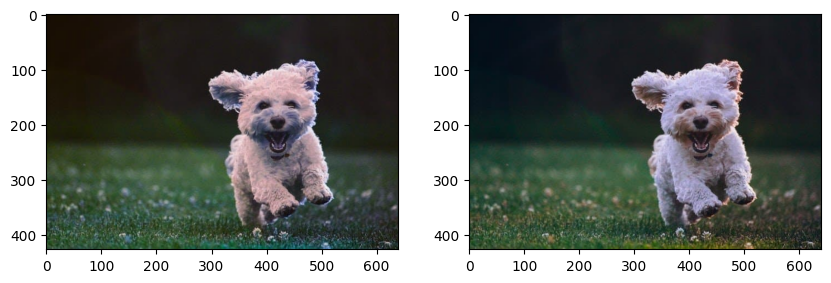

In [ ]:
import matplotlib.pyplot as plt
img = cv2.imread('/content/sample_image.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)

plt.subplot(1, 2, 2)
plt.imshow(img_rgb)

plt.show()